# 🏛️ **Universidad Nacional de Loja**
## **Carrera de Computación**
#### **Facultad de Energía, las Industrias y los Recursos Naturales no Renovables**

---

| **DATOS DE LA PRÁCTICA** | |
| :--- | :--- |
| **Componente:** | Aprendizaje Práctico Experimental (APE) - ABI |
| **Estudiantes:** | • Emerson Sebastian Chamba Galarza<br>• Matias Sebastian Labanda Pineda<br>• Lenin Fabricio Macas Cabrera<br>• Pilar Valentina Naranjo Quizhpe<br>• Mateo Sebastian Pucha Carrera |
| **Profesor:** | Ing. Cristian Narváez G. Mg.Sc. |
| **Unidad:** | Unidad 2 |
| **Paralelo:** | Segundo "A" |
| **Fecha:** | 31/05/2026 |

---



### 📝**Formulación de la Hipótesis de Distribución**

---

**Variable Seleccionada:** Número de viviendas que carecen de servicio de alcantarillado por cantón en la provincia de Loja (`Sin_Alcantarillado`).

* **Hipótesis Nula ($H_0$):** El número de viviendas sin acceso al servicio de alcantarillado en los cantones de la provincia de Loja se ajusta a una Distribución de Poisson.
* **Hipótesis Alternativa ($H_1$):** El número de viviendas sin acceso al servicio de alcantarillado en los cantones de la provincia de Loja no se ajusta a una Distribución de Poisson.

### **🧮Estimación de Parámetros Empíricos**

In [ ]:
import pandas as pd
import numpy as np

# 1. Asegurar la carga de datos
df = pd.read_csv('/content/datos_loja2.csv')
datos_conteo = df['Sin_Alcantarillado'].astype(int)

# 2. Cálculo de los parámetros para el análisis de Poisson
lambda_estimado = datos_conteo.mean()
varianza_muestral = datos_conteo.var()

print("--- PARÁMETROS EMPÍRICOS ESTIMADOS ---")
print(f"Número de cantones evaluados (N): {len(datos_conteo)}")
print(f"Tasa media de ocurrencia (Lambda λ): {lambda_estimado:.2f} viviendas por cantón")
print(f"Varianza muestral: {varianza_muestral:.2f}")

--- PARÁMETROS EMPÍRICOS ESTIMADOS ---
Número de cantones evaluados (N): 16
Tasa media de ocurrencia (Lambda λ): 2382.62 viviendas por cantón
Varianza muestral: 5203416.92


A partir del dataset regional correspondiente a la provincia de Loja, se calcularon los principales parámetros estadísticos de la muestra con el propósito de contrastarlos con los supuestos teóricos de la Distribución de Poisson.

* **Tamaño de la muestra ($N$):** Se consideraron los 16 cantones que conforman la provincia de Loja.
* **Tasa media de ocurrencia ($\lambda$):** La media muestral de la variable `Sin_Alcantarillado` fue de **2.382,62 viviendas por cantón**. En el contexto de una distribución de Poisson, este valor representa la tasa promedio de ocurrencia de eventos esperados.
* **Varianza muestral ($s^2$):** El análisis de dispersión de los datos arrojó una varianza de **5.203.416,92**, evidenciando una elevada variabilidad entre los cantones estudiados.

Uno de los supuestos fundamentales de la Distribución de Poisson es la **equidispersión**, es decir, que la media y la varianza presenten valores iguales o muy similares ($\lambda \approx \sigma^2$). Sin embargo, los resultados obtenidos muestran una diferencia considerable entre ambos parámetros: mientras la media es de 2.382,62, la varianza alcanza 5.203.416,92.

Esta discrepancia matemática indica unívocamente la presencia de una **sobredispersión extrema**, fenómeno que ocurre cuando la variabilidad observada supera ampliamente la varianza esperada bajo el supuesto metodológico de un modelo de Poisson estándar.

### 📊 **Código de Ajuste y Superposición Gráfica**


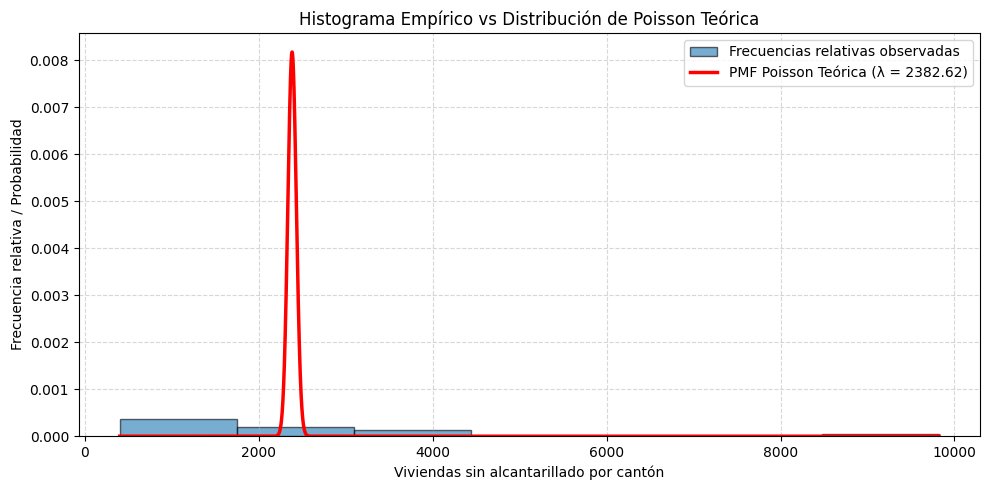

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 1. Cargar datos
df = pd.read_csv('/content/datos_loja2.csv')
datos_conteo = df['Sin_Alcantarillado'].astype(int)

# 2. Estimar lambda
lambda_estimado = datos_conteo.mean()

# 3. Crear histograma de frecuencias relativas
plt.figure(figsize=(10, 5))

plt.hist(
    datos_conteo,
    bins=7,
    density=True,
    alpha=0.6,
    edgecolor='black',
    label='Frecuencias relativas observadas'
)

# 4. Calcular la PMF teórica de Poisson
x = np.arange(
    datos_conteo.min(),
    datos_conteo.max() + 1
)

pmf_poisson = poisson.pmf(
    x,
    mu=lambda_estimado
)

# 5. Superponer la PMF teórica
plt.plot(
    x,
    pmf_poisson,
    'r-',
    linewidth=2.5,
    label=f'PMF Poisson Teórica (λ = {lambda_estimado:.2f})'
)

# 6. Personalización del gráfico
plt.title('Histograma Empírico vs Distribución de Poisson Teórica')
plt.xlabel('Viviendas sin alcantarillado por cantón')
plt.ylabel('Frecuencia relativa / Probabilidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📈 **Análisis de Convergencia Teórica**

Para evaluar si este fenómeno es confiable para realizar predicciones en los próximos años mediante el modelo estadístico planteado, analizamos matemáticamente el cumplimiento de sus dos pilares fundamentales:

1. **Condición de Estabilidad (Equidispersión):**
   La convergencia teórica hacia una distribución de Poisson exige que la tasa media de ocurrencia ($\lambda$) permanezca estable y actúe como el único predictor del sistema, cumpliendo que la media sea igual a la varianza ($\lambda = \sigma^2$). Evaluando nuestros datos empíricos:
   $$\lambda = 2382.62 \quad \text{frente a} \quad s^2 = 5203416.92$$
   Dado que $s^2 \gg \lambda$, la condición de estabilidad matemática se rompe por completo debido a una **sobredispersión extrema**. Una varianza que supera en varios órdenes de magnitud a la media demuestra que el parámetro $\lambda$ no es un estimador estable ni representativo para predecir el comportamiento futuro de la variable en la provincia.

2. **Condición de Aleatoriedad e Independencia:**
   El modelo de Poisson asume que los eventos ocurren de forma estrictamente aleatoria, continua e independiente en el espacio o tiempo. En el caso del acceso al alcantarillado, el fenómeno **no cumple con la aleatoriedad homogénea**. La carencia de este servicio básico está fuertemente correlacionada con factores macroeconómicos, densidad poblacional y los presupuestos de inversión pública específicos de cada cabecera cantonal (por ejemplo, las magnitudes habitacionales del cantón Loja distan por completo de cantones pequeños como Olmedo o Quilanga, destruyendo la suposición de que cada cantón tiene la misma tasa de probabilidad de ocurrencia).

 El fenómeno **NO cumple** con las condiciones de estabilidad y aleatoriedad necesarias. Por lo tanto, el modelo de Poisson **no es confiable** para realizar proyecciones o predicciones en los próximos años; cualquier intento de planificación basado en este diseño subestimará drásticamente el riesgo y el margen de error real de la infraestructura sanitaria en la provincia.

### 📌 **Conclusiones**
---
El análisis realizado permitió determinar que la Distribución de Poisson no proporciona un ajuste adecuado para modelar la variable Sin_Alcantarillado en los cantones de la provincia de Loja. Los resultados obtenidos evidencian que el fenómeno no cumple los supuestos necesarios para garantizar predicciones confiables mediante este modelo. En consecuencia, se recomienda emplear enfoques estadísticos más flexibles, como la Distribución Binomial Negativa o modelos de regresión espacial, que permitan representar de mejor manera la variabilidad observada y generar estimaciones más realistas para la planificación de infraestructura sanitaria.


### 📚 **Referencias Bibliográficas**
---

* **[1]** NCSS Statistical Software. Negative Binomial Regression. Disponible en: https://www.ncss.com/wp-content/themes/ncss/pdf/Procedures/NCSS/Negative_Binomial_Regression.pdf

* **[2]** Devore, J. L. Probabilidad y Estadística para Ingeniería y Ciencias. Disponible en: https://gc.scalahed.com/recursos/files/r161r/w24762w/9D/ProbabilidadEstadIsticaaplicacionesIngenierIa.pdf
